# Notebook for measuring correlation for disk scheme

In [1]:
import os
import sys

def find_project_root(target_folder="masteroppgave"):
    """Find the absolute path of a folder by searching upward."""
    currentdir = os.path.abspath("__file__")  # Get absolute script path
    while True:
        if os.path.basename(currentdir) == target_folder:
            return currentdir  # Found the target folder
        parentdir = os.path.dirname(currentdir)
        if parentdir == currentdir:  # Stop at filesystem root
            return None
        currentdir = parentdir  # Move one level up

# Example usage
project_root = find_project_root("masteroppgave")

if project_root:
    sys.path.append(project_root)
    print(f"Project root found: {project_root}")
else:
    raise RuntimeError("Could not find 'masteroppgave' directory")

from computation.similarity import *
from result_analysis.grid_correlation import plot_grid_corr_varying_layers, plot_grid_corr_varying_resolution_and_layers, plot_grid_corr_varying_resolution


Project root found: /cluster/home/eivindoy/masteroppgave


In [2]:
CITY = "rome" # "rome" or "porto"
MEASURE = "dtw" # "dtw" or "frechet"
SIZE = 1500 #How many trajectories to use
PARALLEL_JOBS = 24

# True sim matrix

In [3]:
file_path = f"../../results_true/similarity_values/{CITY}/{MEASURE}/{CITY}-{MEASURE}-{SIZE}.csv"

print(file_path)

# Read CSV, telling pandas to take the first column as the row labels:
true_sim_matrix_df_unsymetric = pd.read_csv(file_path, index_col=0)

# Function to convert values to float if possible
def convert_to_float(value):
    try:
        return float(value)
    except ValueError:
        return value

# Apply the function to each cell in the DataFrame
true_sim_matrix_df = true_sim_matrix_df_unsymetric.map(convert_to_float)
true_sim_matrix_df = (true_sim_matrix_df + true_sim_matrix_df.T)

../../results_true/similarity_values/rome/dtw/rome-dtw-1500.csv


In [4]:
# plot_grid_corr_varying_layers(
#     city=CITY,
#     layers=[1, 2, 3, 4, 5],
#     true_sim_matrix = true_sim_matrix_df,
#     resolution=1.6,
#     size=SIZE,
#     measure=MEASURE,
#     parallel_jobs=PARALLEL_JOBS,
# )

In [5]:
# plot_grid_corr_varying_resolution(
#     city=CITY,
#     layers=3,
#     true_sim_matrix = true_sim_matrix_df,
#     resolution=[1.6, 4.1, 0.3],
#     size=SIZE,
#     measure=MEASURE,
#     parallel_jobs=PARALLEL_JOBS,
# )

/cluster/home/eivindoy/masteroppgave/result_analysis/grid_correlation.py:275: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(


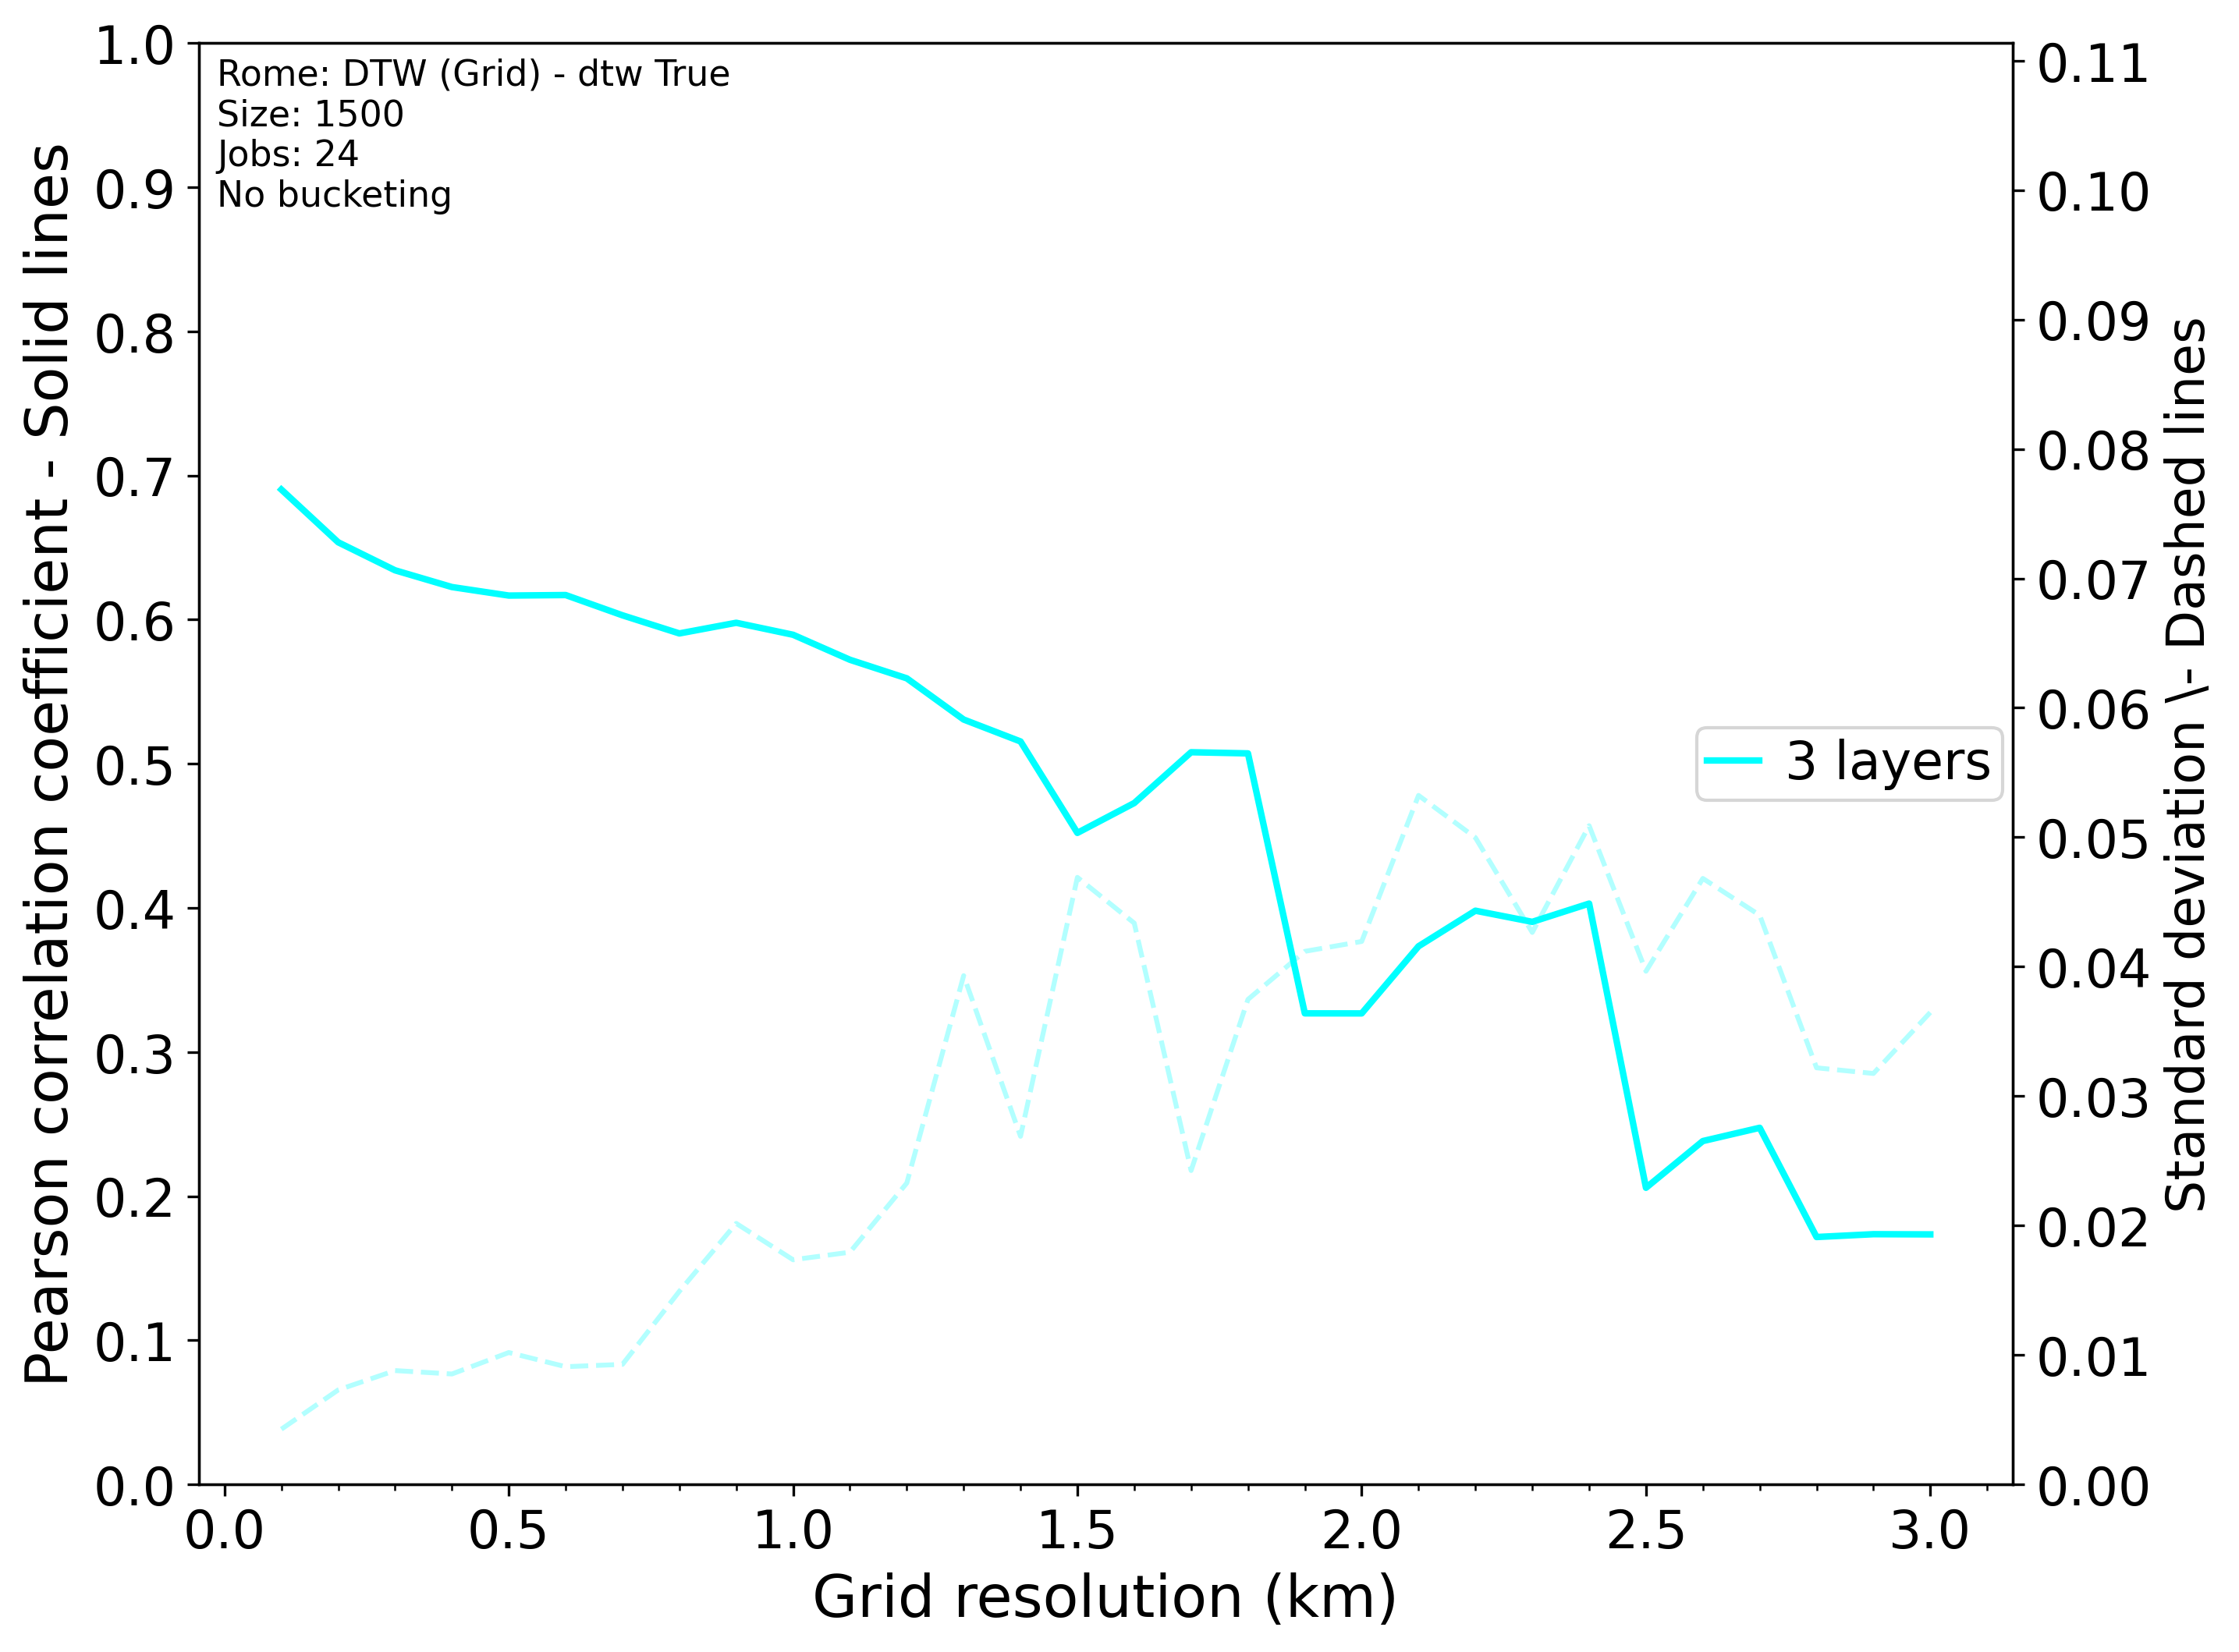

In [4]:
plot_grid_corr_varying_resolution_and_layers(
    city=CITY,
    layers=[3],
    true_sim_matrix = true_sim_matrix_df,
    resolution=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0],
    size=SIZE,
    measure=MEASURE,
    parallel_jobs=PARALLEL_JOBS,
)